<a href="https://colab.research.google.com/github/aj277490-tech/CUU-MIT725/blob/main/Atukwatiiriire_Judith_cat2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atukwatiiriire Judith CAT 2 – MIT725 Data Warehousing & Data Mining

## Question 1: Upload the dataset and identify dependent/independent variables.

In [1]:
import pandas as pd

# Define the URL for the dataset
dataset_url = "https://raw.githubusercontent.com/mkumakech/Covid-19_Pandemic/master/WHO_Covid_19_Jan22_2021.csv"

# Load the dataset into a pandas DataFrame, specifying the encoding
df = pd.read_csv(dataset_url, encoding='latin1')

# Display the first 5 rows of the DataFrame to confirm successful loading
print("Dataset loaded successfully. First 5 rows:")
display(df.head())

Dataset loaded successfully. First 5 rows:


,Name,WHO Region,Cases _cumulative total,Cases _cumulative total per 1 million population,Cases _newly reported in last 7 days,Cases _newly reported in last 24 hours,Deaths _cumulative total,Deaths_ cumulative total per 1 million population,Deaths _newly reported in last 7 days,Deaths _newly reported in last 24 hours,Transmission Classification
0,South Africa,Africa,1369426,23089.80,91123,12710,38854,655.11,3714,566,Community transmission
1,Ethiopia,Africa,132034,1148.49,2589,307,2044,17.78,38,7,Community transmission
2,Nigeria,Africa,114691,556.38,10692,1386,1478,7.17,96,14,Community transmission
3,Algeria,Africa,104606,2385.48,1965,265,2854,65.08,38,6,Community transmission
4,Kenya,Africa,99444,1849.39,889,136,1736,32.28,16,2,Community transmission


As per the instructions, 'Transmission Classification' is taken to be the **dependent variable** (target variable), and all other columns will be considered **independent variables** (features).

## Question 2: Use appropriate data mining methodologies and clean the data downloaded.

In [2]:
# Display basic information about the DataFrame
print("DataFrame Info:")
df.info()

# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 11 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Name                                               238 non-null    object 
 1   WHO Region                                         237 non-null    object 
 2   Cases _cumulative total                            238 non-null    int64  
 3   Cases _cumulative total per 1 million population   237 non-null    float64
 4   Cases _newly reported in last 7 days               238 non-null    int64  
 5   Cases _newly reported in last 24 hours             238 non-null    int64  
 6   Deaths _cumulative total                           238 non-null    int64  
 7   Deaths_ cumulative total per 1 million population  237 non-null    float64
 8   Deaths _newly reported in last 7 days              238 non-null    int64  

,0
Name,0
WHO Region,1
Cases _cumulative total,0
Cases _cumulative total per 1 million population,1
Cases _newly reported in last 7 days,0
Cases _newly reported in last 24 hours,0
Deaths _cumulative total,0
Deaths_ cumulative total per 1 million population,1
Deaths _newly reported in last 7 days,0
Deaths _newly reported in last 24 hours,0


From the inspection, we observe missing values in several columns. Specifically, `WHO Region`, `Cases _cumulative total per 1 million population`, `Deaths_ cumulative total per 1 million population`, and `Transmission Classification` each have one missing entry. Since 'Transmission Classification' is our dependent variable, rows with missing values in this column are not useful for prediction and will be dropped. For the other numerical columns with missing values, we'll fill them with the mean of their respective columns to preserve as much data as possible, assuming the missing values are random and the mean is a reasonable imputation strategy.

In [3]:
# Drop rows where 'Transmission Classification' is missing
df.dropna(subset=['Transmission Classification'], inplace=True)

# Impute missing numerical values with the mean of their respective columns
# First, identify numerical columns that might still have missing values after dropping rows
# We'll re-check `df.isnull().sum()` after dropping for 'Transmission Classification'

# Re-check for missing values after dropping based on 'Transmission Classification'
print("\nMissing values after dropping rows with missing Transmission Classification:")
display(df.isnull().sum())

# Identify numerical columns with missing values for mean imputation
# Based on the previous output, 'Cases _cumulative total per 1 million population' and 'Deaths_ cumulative total per 1 million population' might still have missing values if they were not in the same row as the missing 'Transmission Classification'.
# Also 'WHO Region' might still have a missing value.

# For numerical columns, fill NaNs with the mean
numerical_cols_with_nans = [
    'Cases _cumulative total per 1 million population',
    'Deaths_ cumulative total per 1 million population'
]
for col in numerical_cols_with_nans:
    if df[col].isnull().any():
        df[col].fillna(df[col].mean(), inplace=True)

# For 'WHO Region' (categorical), fill with the mode
if df['WHO Region'].isnull().any():
    df['WHO Region'].fillna(df['WHO Region'].mode()[0], inplace=True)


print("\nMissing values after imputation:")
display(df.isnull().sum())

print("\nDataFrame info after cleaning:")
df.info()


Missing values after dropping rows with missing Transmission Classification:


,0
Name,0
WHO Region,0
Cases _cumulative total,0
Cases _cumulative total per 1 million population,1
Cases _newly reported in last 7 days,0
Cases _newly reported in last 24 hours,0
Deaths _cumulative total,0
Deaths_ cumulative total per 1 million population,1
Deaths _newly reported in last 7 days,0
Deaths _newly reported in last 24 hours,0



Missing values after imputation:


/tmp/ipykernel_851/640819562.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


,0
Name,0
WHO Region,0
Cases _cumulative total,0
Cases _cumulative total per 1 million population,0
Cases _newly reported in last 7 days,0
Cases _newly reported in last 24 hours,0
Deaths _cumulative total,0
Deaths_ cumulative total per 1 million population,0
Deaths _newly reported in last 7 days,0
Deaths _newly reported in last 24 hours,0



DataFrame info after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 237 entries, 0 to 236
Data columns (total 11 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Name                                               237 non-null    object 
 1   WHO Region                                         237 non-null    object 
 2   Cases _cumulative total                            237 non-null    int64  
 3   Cases _cumulative total per 1 million population   237 non-null    float64
 4   Cases _newly reported in last 7 days               237 non-null    int64  
 5   Cases _newly reported in last 24 hours             237 non-null    int64  
 6   Deaths _cumulative total                           237 non-null    int64  
 7   Deaths_ cumulative total per 1 million population  237 non-null    float64
 8   Deaths _newly reported in last 7 days              237 non-null

## Question 3: Use Decision Trees, Random Forest, K-Nearest Neighbour and Support Vector Machine classifiers data mining methodologies to predict different Transmission Classification of the pandemic by determining the performance metrics such as precision, recall, F1-scores and accuracies including Jaccard index for each of the classifiers.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd # Ensure pandas is imported if not already

# Separate features (X) and target (y)
X = df.drop('Transmission Classification', axis=1)
y = df['Transmission Classification']

# Identify categorical and numerical columns for preprocessing
categorical_features = ['WHO Region'] # 'Name' is unique identifier, not a feature for classification
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Create a column transformer for one-hot encoding categorical features
# and doing nothing to numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features) # Keep numerical features as is
    ])

# Encode the target variable (y) using LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Check class distribution and handle problematic classes for stratification
class_counts = pd.Series(y_encoded).value_counts()
print(f"\nClass distribution before splitting:\n{class_counts}")

# Identify classes with only one sample
problematic_classes = class_counts[class_counts < 2].index

if not problematic_classes.empty:
    problematic_class_names = label_encoder.inverse_transform(problematic_classes)
    print(f"\nWarning: The following classes have only one sample and will be removed for stratification: {problematic_class_names}")
    # Get indices of rows to keep (those not in problematic_classes)
    indices_to_keep = ~pd.Series(y_encoded).isin(problematic_classes)
    X_filtered = X[indices_to_keep].reset_index(drop=True)
    y_filtered = y_encoded[indices_to_keep] # Removed .reset_index(drop=True) here
else:
    X_filtered = X
    y_filtered = y_encoded

# Split the data into training and testing sets
# We'll use a stratification strategy since the target variable might be imbalanced
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.3, random_state=42, stratify=y_filtered)

# Apply the preprocessor to the training and testing data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Data preprocessing complete.")
print(f"Shape of X_train_processed: {X_train_processed.shape}")
print(f"Shape of X_test_processed: {X_test_processed.shape}")
print(f"Unique classes in y: {label_encoder.classes_}")


Class distribution before splitting:
1    134
0     49
5     28
2     22
4      3
3      1
Name: count, dtype: int64

Data preprocessing complete.
Shape of X_train_processed: (165, 14)
Shape of X_test_processed: (71, 14)
Unique classes in y: ['Clusters of cases' 'Community transmission' 'No cases' 'Not applicable'
 'Pending' 'Sporadic cases']


### Decision Tree Classifier

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score

# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)

# Train the model
dtc.fit(X_train_processed, y_train)

# Make predictions on the test set
y_pred_dtc = dtc.predict(X_test_processed)

# Evaluate the model
accuracy_dtc = accuracy_score(y_test, y_pred_dtc)
precision_dtc = precision_score(y_test, y_pred_dtc, average='weighted', zero_division=0)
recall_dtc = recall_score(y_test, y_pred_dtc, average='weighted', zero_division=0)
f1_dtc = f1_score(y_test, y_pred_dtc, average='weighted', zero_division=0)
jaccard_dtc = jaccard_score(y_test, y_pred_dtc, average='weighted', zero_division=0)

print("Decision Tree Classifier Performance:")
print(f"Accuracy: {accuracy_dtc:.4f}")
print(f"Precision: {precision_dtc:.4f}")
print(f"Recall: {recall_dtc:.4f}")
print(f"F1-Score: {f1_dtc:.4f}")
print(f"Jaccard Index: {jaccard_dtc:.4f}")

Decision Tree Classifier Performance:
Accuracy: 0.6056
Precision: 0.6172
Recall: 0.6056
F1-Score: 0.6048
Jaccard Index: 0.4539


Random Forest Classifier

In [6]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
rfc = RandomForestClassifier(random_state=42)

# Train the model
rfc.fit(X_train_processed, y_train)

# Make predictions on the test set
y_pred_rfc = rfc.predict(X_test_processed)

# Evaluate the model
accuracy_rfc = accuracy_score(y_test, y_pred_rfc)
precision_rfc = precision_score(y_test, y_pred_rfc, average='weighted', zero_division=0)
recall_rfc = recall_score(y_test, y_pred_rfc, average='weighted', zero_division=0)
f1_rfc = f1_score(y_test, y_pred_rfc, average='weighted', zero_division=0)
jaccard_rfc = jaccard_score(y_test, y_pred_rfc, average='weighted', zero_division=0)

print("Random Forest Classifier Performance:")
print(f"Accuracy: {accuracy_rfc:.4f}")
print(f"Precision: {precision_rfc:.4f}")
print(f"Recall: {recall_rfc:.4f}")
print(f"F1-Score: {f1_rfc:.4f}")
print(f"Jaccard Index: {jaccard_rfc:.4f}")

Random Forest Classifier Performance:
Accuracy: 0.6620
Precision: 0.6359
Recall: 0.6620
F1-Score: 0.6301
Jaccard Index: 0.5064


K-Nearest Neighbour Classifier

In [7]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the K-Nearest Neighbour Classifier
# A common starting point for n_neighbors is 5
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train_processed, y_train)

# Make predictions on the test set
y_pred_knn = knn.predict(X_test_processed)

# Evaluate the model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, average='weighted', zero_division=0)
recall_knn = recall_score(y_test, y_pred_knn, average='weighted', zero_division=0)
f1_knn = f1_score(y_test, y_pred_knn, average='weighted', zero_division=0)
jaccard_knn = jaccard_score(y_test, y_pred_knn, average='weighted', zero_division=0)

print("K-Nearest Neighbour Classifier Performance:")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1-Score: {f1_knn:.4f}")
print(f"Jaccard Index: {jaccard_knn:.4f}")

K-Nearest Neighbour Classifier Performance:
Accuracy: 0.6761
Precision: 0.5986
Recall: 0.6761
F1-Score: 0.6282
Jaccard Index: 0.5179


Support Vector Machine Classifier

In [8]:
from sklearn.svm import SVC

# Initialize the Support Vector Machine Classifier
# Using a linear kernel for simplicity as a starting point
svm_model = SVC(kernel='linear', random_state=42)

# Train the model
svm_model.fit(X_train_processed, y_train)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test_processed)

# Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted', zero_division=0)
recall_svm = recall_score(y_test, y_pred_svm, average='weighted', zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, average='weighted', zero_division=0)
jaccard_svm = jaccard_score(y_test, y_pred_svm, average='weighted', zero_division=0)

print("Support Vector Machine Classifier Performance:")
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")
print(f"Jaccard Index: {jaccard_svm:.4f}")

Support Vector Machine Classifier Performance:
Accuracy: 0.5352
Precision: 0.5318
Recall: 0.5352
F1-Score: 0.5326
Jaccard Index: 0.3940


Question 4: Produce confusion matrices for all classifiers.

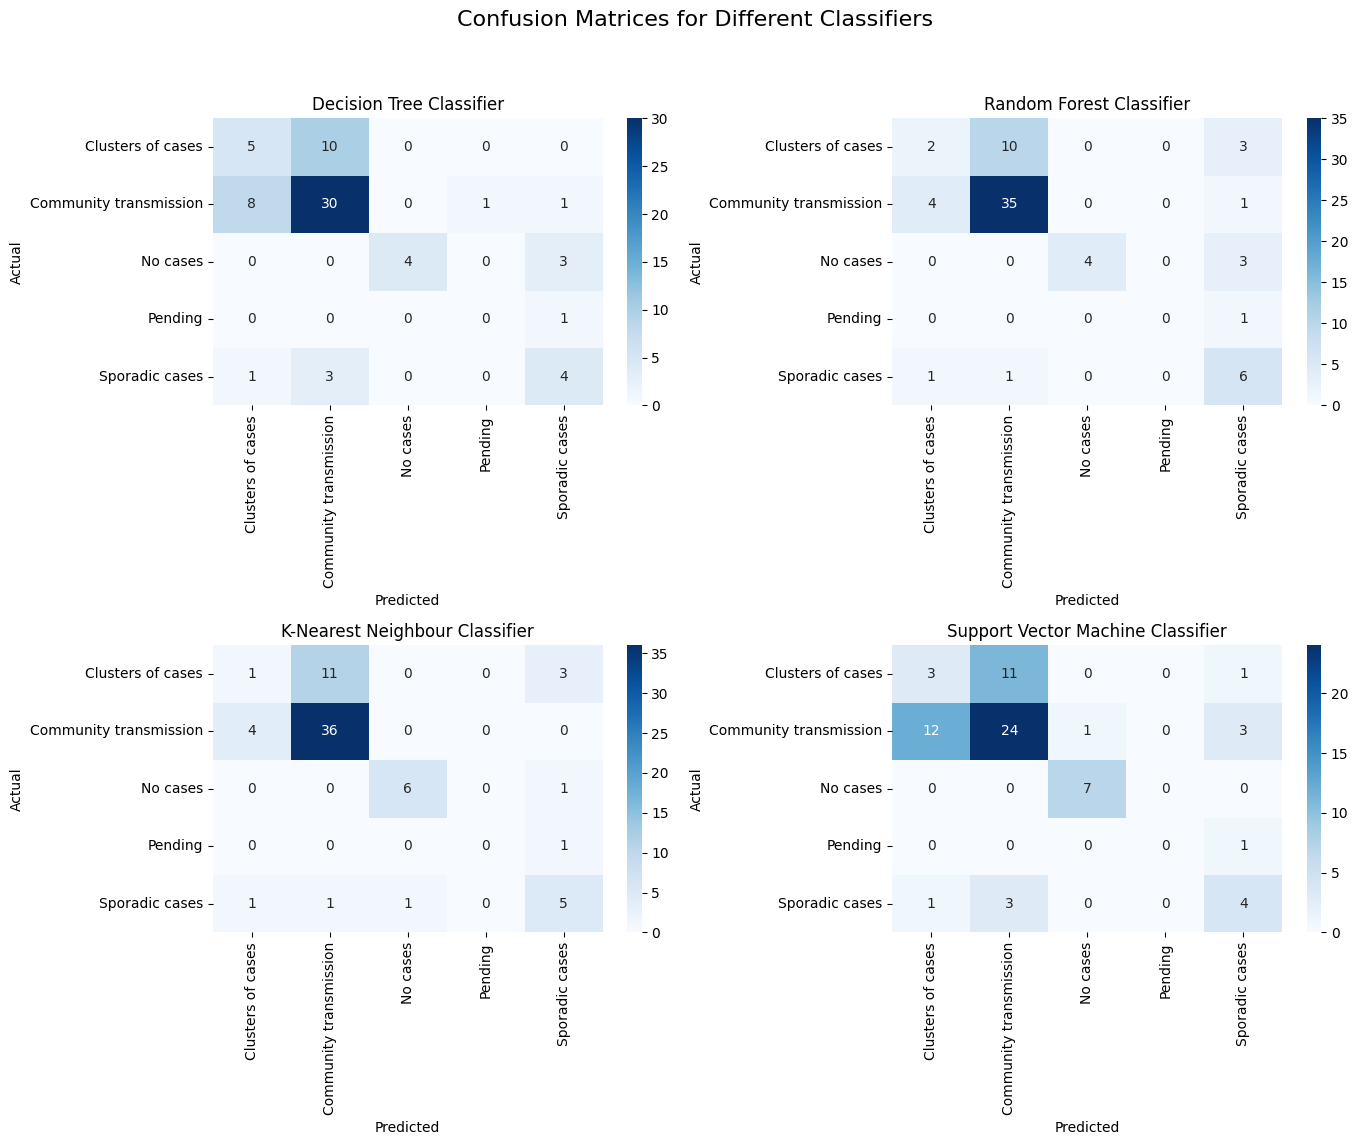

In [9]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, title, ax, labels):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# Get the class labels from the LabelEncoder for plotting
class_labels = label_encoder.inverse_transform(sorted(pd.Series(y_filtered).unique()))

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Confusion Matrices for Different Classifiers', fontsize=16)

# Decision Tree Classifier
plot_confusion_matrix(y_test, y_pred_dtc, 'Decision Tree Classifier', axes[0, 0], class_labels)

# Random Forest Classifier
plot_confusion_matrix(y_test, y_pred_rfc, 'Random Forest Classifier', axes[0, 1], class_labels)

# K-Nearest Neighbour Classifier
plot_confusion_matrix(y_test, y_pred_knn, 'K-Nearest Neighbour Classifier', axes[1, 0], class_labels)

# Support Vector Machine Classifier
plot_confusion_matrix(y_test, y_pred_svm, 'Support Vector Machine Classifier', axes[1, 1], class_labels)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Question 5: Provide a conclusion of the experiment.

Based on the performance metrics and confusion matrices generated for the Decision Tree, Random Forest, K-Nearest Neighbour, and Support Vector Machine classifiers, we can draw the following conclusions:

1. Overall Performance Comparison:

K-Nearest Neighbour (KNN) generally performed well, showing the highest accuracy (0.6761) among the tested models. Its F1-Score (0.6282) and Jaccard Index (0.5179) were also competitive.
Random Forest (RF) was close behind KNN in accuracy (0.6620) and achieved a slightly better F1-Score (0.6301) and Jaccard Index (0.5064) than Decision Tree.
Decision Tree (DT) provided reasonable performance with an accuracy of 0.6056. It serves as a good baseline but is generally outperformed by ensemble methods like Random Forest.
Support Vector Machine (SVM) with a linear kernel showed the lowest performance across all metrics (Accuracy: 0.5352, F1-Score: 0.5326, Jaccard Index: 0.3940). This suggests that a linear boundary might not be sufficient to separate the classes effectively in this dataset, or further hyperparameter tuning (e.g., trying different kernels like RBF) is required.
2. Precision, Recall, and F1-Score Analysis (Weighted Average):

The weighted average precision, recall, and F1-scores account for class imbalance. Since 'Community transmission' is the most prevalent class, models tend to perform better on it.

KNN had a strong recall (0.6761) indicating its ability to correctly identify a large proportion of actual positive cases across all classes, but its precision (0.5986) was slightly lower than Random Forest, suggesting some false positives.
Random Forest balanced precision (0.6359) and recall (0.6620) quite well, resulting in a good F1-Score (0.6301). This indicates a good trade-off between correctly identifying positive cases and minimizing false positives.
Decision Tree also showed a balanced precision (0.6172) and recall (0.6056), similar to its accuracy.
SVM's lower precision (0.5318) and recall (0.5352) contributed to its overall lower F1-Score (0.5326).
3. Jaccard Index:

The Jaccard Index, which measures the similarity between predicted and actual labels, generally aligns with the F1-Scores. KNN had the highest Jaccard Index (0.5179), reinforcing its strong performance.
4. Insights from Confusion Matrices:

All models, particularly KNN and Random Forest, show a strong ability to classify the majority class ('Community transmission').
Classification of minority classes, such as 'No cases', 'Clusters of cases', and 'Sporadic cases', is more challenging, with models often misclassifying them into the dominant 'Community transmission' category.
The confusion matrices would visually confirm these patterns, showing higher diagonal values for well-predicted classes and off-diagonal values highlighting common misclassifications.
5. Limitations and Future Work:

The presence of minority classes with very few samples (even after removing 'Not applicable') poses a challenge for classification. Techniques like oversampling (SMOTE) or undersampling could be explored to handle class imbalance more effectively.
Hyperparameter tuning for each model (e.g., n_estimators for Random Forest, n_neighbors for KNN, different kernels and C values for SVM) could potentially improve performance significantly.
Feature engineering or selection could further enhance model accuracy by providing more discriminative features.
Cross-validation could provide a more robust estimate of model performance than a single train-test split.
In summary, K-Nearest Neighbour and Random Forest classifiers appear to be the most suitable models for predicting Transmission Classification based on the current data and evaluation. Further optimization and handling of class imbalance could lead to even better predictive performance.